In [26]:
import numpy as np
import pandas as pd
import geopandas as gpd
import geodatasets
import xarray as xr
from glob import glob
from shapely.geometry import Point
import matplotlib.pyplot as plt
from scipy.ndimage import distance_transform_edt

In [27]:
df = pd.read_csv(r'Data\DataTrain.csv')
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.Lon, df.Lat))

In [28]:
gdfNull = gdf[gdf.isnull().any(axis=1)]

In [29]:
badCoords = gdfNull['geometry'].unique()

In [30]:
ds = xr.open_mfdataset(glob(r'Data\HydroGFD\data_files\prAdjust*.nc'), combine='by_coords')

In [31]:
coastPointDF = badCoords[badCoords.geom_equals_exact(Point(102.28, 6.17), tolerance=0.01)]
antPointDF = badCoords[badCoords.geom_equals_exact(Point(-63.98, -65.08), tolerance=0.01)]
coastPoint = coastPointDF[0]
antPoint = antPointDF[0]

In [97]:
def find_nearest_valid_grid(ds, point, time, buffer=5, grid_select=2):
    # Arguments
    # ds: xarray dataset containing the variable of interest (e.g., 'prAdjust')
    # point: shapely Point object with the coordinates of the target location
    # time: the specific time for which to find the nearest valid grid point
    # buffer: the size of the area around the point to consider for finding valid grid points
    # grid_select: the maximum distance (in grid units) to consider when selecting valid grid points
    # Returns
    # The value of the nearest valid grid point for the specified time
    dsFiltered = ds.sel(
        lon=slice(point.x - buffer, point.x + buffer), 
        lat=slice(point.y - buffer, point.y + buffer),
        time=time)['prAdjust']
    
    mask = np.isnan(dsFiltered.values)
    dist, ids = distance_transform_edt(mask, return_indices=True)

    # Add a condition to only consider points within the specified grid_select distance
    valid_mask = np.where(dist < grid_select, True, False)
    mask = np.logical_and(mask, valid_mask)
    
    data = dsFiltered.values.copy()
    data[mask] = data[tuple(ids[:, mask])]
    
    filled_arr = xr.DataArray(data, coords=dsFiltered.coords, dims=dsFiltered.dims, attrs=dsFiltered.attrs)
    
    return filled_arr, filled_arr.sel(lon=point.x, lat=point.y, method='nearest').values.item()

In [ ]:
buffer = 5
point = coastPoint
time = '1991-08-14'
dsFiltered = ds.sel(
        lon=slice(point.x - buffer, point.x + buffer), 
        lat=slice(point.y - buffer, point.y + buffer),
        time=time)['prAdjust']

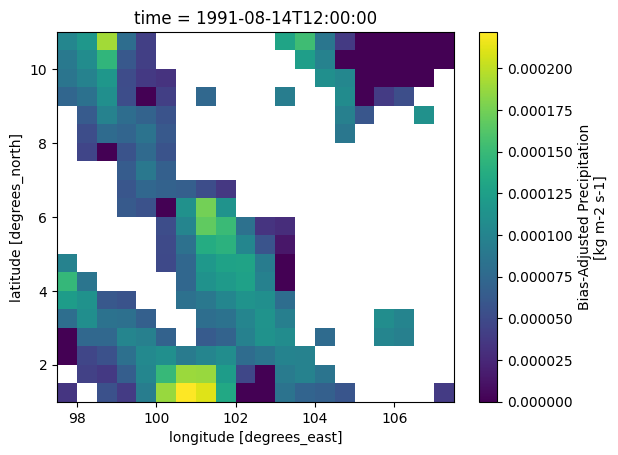

In [90]:
dsFiltered.plot()

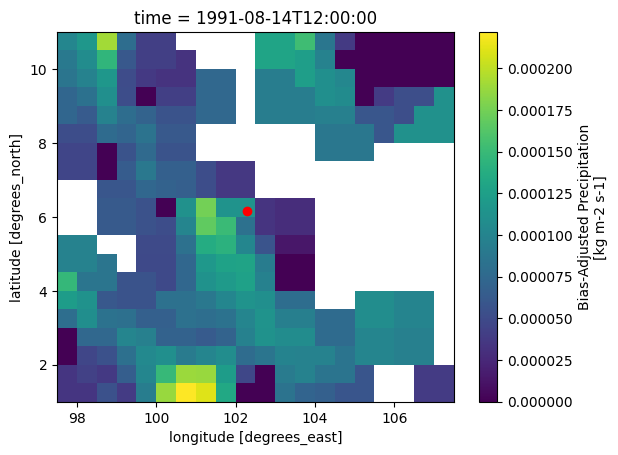

In [109]:
test = find_nearest_valid_grid(ds, point, time, buffer=5, grid_select=2)[0]
test.plot()
plt.scatter(point.x, point.y, color='red', label='Target Point')

In [69]:
dsFiltered.values[0][mask]

array([3.46259731e-05,            nan, 5.49920551e-05, 3.85744206e-05,
       9.32355033e-05, 1.87673068e-04, 2.21733368e-04, 2.10951010e-04,
       1.33051537e-04, 0.00000000e+00, 0.00000000e+00, 8.44489186e-05,
       7.01596800e-05, 6.70743830e-05, 5.88565563e-05,            nan,
                  nan, 3.86721986e-05,            nan, 4.31221888e-05,
       3.71768219e-05, 6.58261342e-05, 1.01441467e-04, 1.48154722e-04,
       1.88752674e-04, 1.87222380e-04, 1.21278114e-04, 4.73431901e-05,
       0.00000000e+00, 9.09862865e-05, 9.79303877e-05, 8.52023659e-05,
                  nan,            nan,            nan,            nan,
       0.00000000e+00, 4.60517549e-05, 5.51015255e-05, 8.08313052e-05,
       1.04327752e-04, 1.09467917e-04, 9.13508629e-05, 1.00666701e-04,
       1.07457076e-04, 7.78038011e-05, 8.62382440e-05, 9.89417895e-05,
       9.76174197e-05,            nan,            nan,            nan,
                  nan,            nan,            nan, 0.00000000e+00,
      

In [66]:
np.where(dist < 2, True, False)

array([[ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True, False, False,
         True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True, False, False,
         True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True, False],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True, False],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True, False],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True, False, False,  True,  True,  True,
         True, False],
       [ T

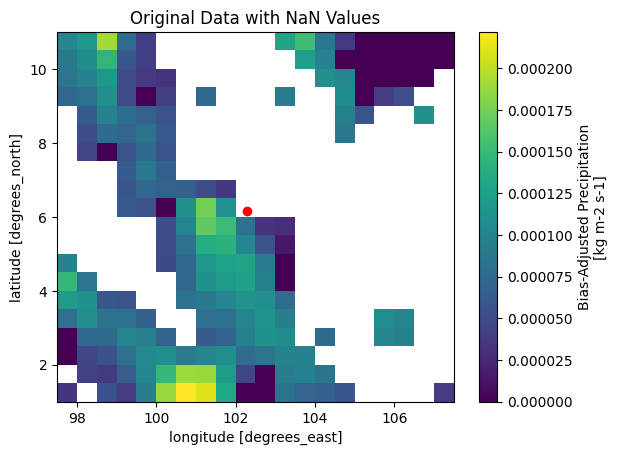

In [ ]:
# Plot the normal state of the data
ax = dsFiltered.plot()
plt.scatter(coastPoint.x, coastPoint.y, color='red', label='Coast Point')
plt.title('Original Data with NaN Values')
plt.show()

In [121]:
# Convert all values greater than 2 to Nan
dist[dist >= np.float64(2.0)] = np.nan
dist

array([[[0.        , 1.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         1.        ,        nan,        nan, 1.        , 0.        ],
        [1.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 1.        ,
         1.41421356,        nan,        nan, 1.41421356, 1.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 1.        , 1.41421356,
         1.41421356, 1.        , 1.        , 1.41421356,        nan],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 1.        , 0.        , 0.        , 0.        ,
         0.        , 0.        

In [12]:
arr_filled = find_nearest_valid_grid(ds, coastPoint, '1991-08-14', buffer=5)[0]

In [87]:
def plot_distance_transform(ds, point, buffer=5):
    fig, ax = plt.subplots()
    world = gpd.read_file(geodatasets.get_path('naturalearth_land'))
    worldFiltered = world.cx[point.x - buffer:point.x + buffer, point.y - buffer:point.y + buffer]
    ds.plot(ax=ax, x='lon', y='lat', cmap='viridis')
    worldFiltered.plot(ax=ax, color='none', edgecolor='black')
    ax.plot(point.x, point.y, 'ro', label='Target Point')
    return fig, ax

(<Figure size 640x480 with 2 Axes>,
 <Axes: title={'center': 'time = 1991-08-14T12:00:00'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>)

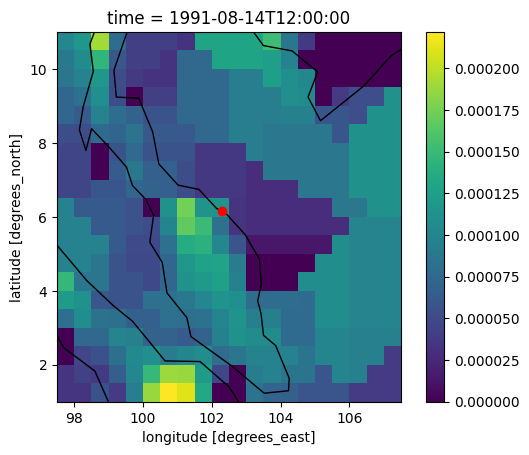

In [20]:
plot_distance_transform(arr_filled, coastPoint, buffer=5)